# Solving Median House Value classification problem implementing a deep neural network with ReLU
### Keras

This experiment shows how the training process dramatically speeds up and the accuracy increases by employing the same neural architecture as the previous experiment except for the activation function in the hidden layers, now ReLU, which does not saturate for high net inputs: *small tweaks have huge positive impact in performance.*      

This experiment shows that it is possible to train deep artificial neural networks by using activation functions that do not saturate for high values of the net input such as ReLU.

Code by [D. Manrique](https://orcid.org/0000-0002-0792-4156)

## Import libraries

In [3]:
# Tensorflow and tf.keras
import tensorflow as tf
from tensorflow import keras
print("Tensorflow version:",tf.__version__)
print("Keras version:",keras.__version__)

#Helper libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Tensorflow version: 2.19.0
Keras version: 3.9.2


## Load data

In [6]:
ATT_FILE = "MedianHouseValuePreparedCleanAttributes.csv"
LABEL_FILE = "MedianHouseValueOneHotEncodedClasses.csv"

TRAIN_RATE=0.8

attributes = pd.read_csv(ATT_FILE)
label = pd.read_csv(LABEL_FILE)

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATE)
n_dev = int((n_instances-n_train)/2)

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]

x_dev = attributes.values[n_train:n_train+n_dev]
t_dev = label.values[n_train:n_train+n_dev]

print ("x_train:",x_train.shape)
print ("t_train:",t_train.shape)

print ("x_dev:",x_dev.shape)
print ("t_dev:",t_dev.shape)

x_train: (16342, 9)
t_train: (16342, 3)
x_dev: (2043, 9)
t_dev: (2043, 3)


## Initialization

In [9]:
INPUTS = x_train.shape[1]
OUTPUTS = t_train.shape[1]
NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES = int (round (x_dev.shape[0]/1))

In [11]:
x_train[:5]

array([[-0.61752988,  0.11583422,  1.        , -0.81875986, -0.72346369,
        -0.9229799 , -0.72011182, -0.54388215,  0.33333333],
       [ 0.1812749 , -0.64718385, -0.09803922, -0.83997151, -0.71849783,
        -0.84041033, -0.72438744, -0.79931311, -1.        ],
       [ 0.33665339, -0.79383634, -0.45098039, -0.91144005, -0.92147734,
        -0.94730794, -0.91021214, -0.2504931 , -1.        ],
       [-0.93625498,  0.68119022,  0.29411765, -0.94892924, -0.93420236,
        -0.97533563, -0.94836376, -0.7090385 , -1.        ],
       [ 0.25697211, -0.68119022,  0.33333333, -0.91189786, -0.88764742,
        -0.9145716 , -0.88718961, -0.65516338, -1.        ]])

In [19]:
t_train[:10]

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [21]:
x_dev[:5]

array([[-0.61553785,  0.10945802,  1.        , -0.89389084, -0.84916201,
        -0.93951624, -0.83982898, -0.69925932,  0.33333333],
       [-0.17131474,  0.17534538,  0.64705882, -0.99491327, -0.99441341,
        -0.99770173, -0.99605328, -1.        , -0.33333333],
       [ 0.02390438, -0.63443146,  0.17647059, -0.98870746, -0.97299814,
        -0.98189411, -0.97138629, -0.74136908,  1.        ],
       [ 0.29083665, -0.65993624,  0.1372549 , -0.87318785, -0.81843575,
        -0.93632109, -0.81647755, -0.66378395, -0.33333333],
       [ 0.20717131, -0.68119022,  0.84313725, -0.93127829, -0.84885164,
        -0.89114045, -0.84015787, -0.7329692 , -1.        ]])

In [23]:
t_dev[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

## Hyperparameters

A 9-10,000-10,000-10,000-3 neural architecture.

In [27]:
n_epochs = 600
lr = 0.1
batch_size = 512
n_neurons_per_hlayer = [10000,10000, 10000]

## Build the deep neural model

In [30]:
model = keras.Sequential(name="Feedforward_NN")

In [32]:
model.add(keras.layers.InputLayer(shape=(INPUTS,), batch_size=None))

for neurons in n_neurons_per_hlayer:
  model.add(keras.layers.Dense(neurons, activation="relu"))

model.add(keras.layers.Dense(OUTPUTS, activation="softmax"))
#model.summary()

# Compiling the model

Available loss functions, optimizers, and metrics at: https://keras.io/losses/, https://keras.io/optimizers/ and https://keras.io/metrics/.


In [36]:
model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["categorical_accuracy"])

## Training the model with M-BGD

In [ ]:
import time
start = time.perf_counter()
history = model.fit(x_train, t_train, batch_size=batch_size, epochs=n_epochs, verbose=1, validation_data=(x_dev, t_dev))
print (time.perf_counter() - start)

Train on 16342 samples, validate on 2043 samples
Epoch 1/600
16342/16342 [==============================] - 4s 226us/sample - loss: 1.0575 - categorical_accuracy: 0.5398 - val_loss: 1.0096 - val_categorical_accuracy: 0.6535
Epoch 2/600
16342/16342 [==============================] - 3s 178us/sample - loss: 0.9534 - categorical_accuracy: 0.6408 - val_loss: 0.8681 - val_categorical_accuracy: 0.6672
Epoch 3/600
16342/16342 [==============================] - 3s 179us/sample - loss: 0.8427 - categorical_accuracy: 0.6333 - val_loss: 0.7576 - val_categorical_accuracy: 0.6711
Epoch 4/600
16342/16342 [==============================] - 3s 178us/sample - loss: 0.7974 - categorical_accuracy: 0.6282 - val_loss: 0.7054 - val_categorical_accuracy: 0.6858
Epoch 5/600
16342/16342 [==============================] - 3s 179us/sample - loss: 0.7773 - categorical_accuracy: 0.6413 - val_loss: 0.7252 - val_categorical_accuracy: 0.6608
Epoch 6/600
16342/16342 [==============================] - 3s 178us/sample -

## Get the results

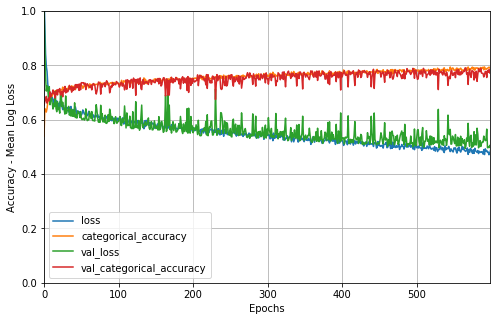

In [ ]:
results=pd.DataFrame(history.history)
results.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Note how the accuracy incresases and the mean log-loss decreases in both training and development test sets.

In [ ]:
history.params

{'batch_size': 500,
 'do_validation': True,
 'epochs': 600,
 'metrics': ['loss',
  'categorical_accuracy',
  'val_loss',
  'val_categorical_accuracy'],
 'samples': 16342,
 'steps': None,
 'verbose': 0}

In [ ]:
results[-1:]

,loss,categorical_accuracy,val_loss,val_categorical_accuracy
599,0.487296,0.785644,0.500722,0.783162


In [ ]:
print ("Accuracy for the training set: ", results.categorical_accuracy.values[-1:][0])

Accuracy for the training set:  0.7856443524360657


In [ ]:
print ("Accuracy for the development test set: ", results.val_categorical_accuracy.values[-1:][0])

Accuracy for the development test set:  0.783161997795105


Now the accuracy is 78.5% on training and 78% on the develoment test set.  

Are these good results?

1.   It depends on the base error we assume (also called Bayes error or minimum error). If we consider that a human or the best up-to-date machine learning system can achieve an accuracy of 100% (0% error), this is a poor result; the model underfits the dataset. It cannot accurately classify the training examples. Instead, if the base error is 20% (80% of accuracy), we have a good neural model. The difference between the training error and the estimation of the Bayes error is called *bias*.

2.   It is also essential to detect overfitting by comparing the training and dev errors (called *variance*). The results achieved report that the model does not overfit since they are similar. This means that the model generalizes well, although it achieves poor classification results compared to a base error of 0%. On the contrary, if the dev test accuracy is, let's say, 65%, then the model suffers from overfitting; it provides much worse results in dev than in training. The learning curve above also provides clues in this respect: we do not observe that the dev loss (in green) increases as the training loss (blue) decreases. Similarly, the dev accuracy (red) does not decrease as the train accuracy increases (orange).  

Therefore a good neural model gets a training error close to the base error (low bias) without overfitting, being the dev error close to the training error (low variance), which means that it generalizes well: it provides good predictions to unseen data (not present in the training set).

Our model generalizes well, but its accuracy must be increased, assuming for this problem a base error of 15% (85% of accuracy). Therefore, we must improve this model. We'll see deep learning techniques during the course to do so.  

Finally, it is noteworthy that we are not using the final test set since we believe that we can improve the neural model by improving the hyperparameters and applying more deep learning techniques.

Let's see how the model predicts on the development test set:

In [ ]:
dev_predictions=model.predict(x_dev).round(2)
dev_predictions[:20]


array([[0.18, 0.8 , 0.01],
       [0.  , 0.02, 0.98],
       [0.85, 0.14, 0.01],
       [0.11, 0.8 , 0.1 ],
       [0.26, 0.67, 0.06],
       [0.01, 0.49, 0.5 ],
       [0.  , 0.22, 0.78],
       [0.  , 0.01, 0.99],
       [0.01, 0.  , 0.99],
       [0.65, 0.34, 0.02],
       [0.06, 0.81, 0.13],
       [0.68, 0.3 , 0.02],
       [0.93, 0.05, 0.02],
       [0.28, 0.46, 0.26],
       [0.89, 0.11, 0.01],
       [0.  , 0.04, 0.96],
       [0.99, 0.01, 0.  ],
       [0.  , 0.01, 0.99],
       [0.01, 0.96, 0.03],
       [0.01, 0.02, 0.98]], dtype=float32)

In [ ]:
dev_rounded_predictions=np.round(dev_predictions)
indices = np.argmax(dev_predictions,1)
for row, index in zip(dev_rounded_predictions, indices): row[index]=1
dev_rounded_predictions[:20]

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [ ]:
t_dev[:20] #target classes

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [ ]:
dev_correct_predictions = np.equal(np.argmax(dev_rounded_predictions,1),np.argmax(t_dev,1))
print (dev_correct_predictions[:30])

[False  True  True  True  True False  True  True  True False  True False
  True False  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True]


In [ ]:
from collections import Counter
Counter (dev_correct_predictions)

Counter({False: 445, True: 1598})

This model makes less mistakes than the deep-tanh neural network.   